- conditional edge를 활용
- 생성한 답변이 좋으면 generate로, 나쁘면 사용자의 질문을 rewrite로 수정한 다음, 문서를 다시 가져오는 절차
- [검증] 노드가 추가됨

In [1]:
# 필요한 노드

# 1. retrieve
# 2. generate
# 3. rewrite (conditional edge에서 활용)
# 4. 문서 검증

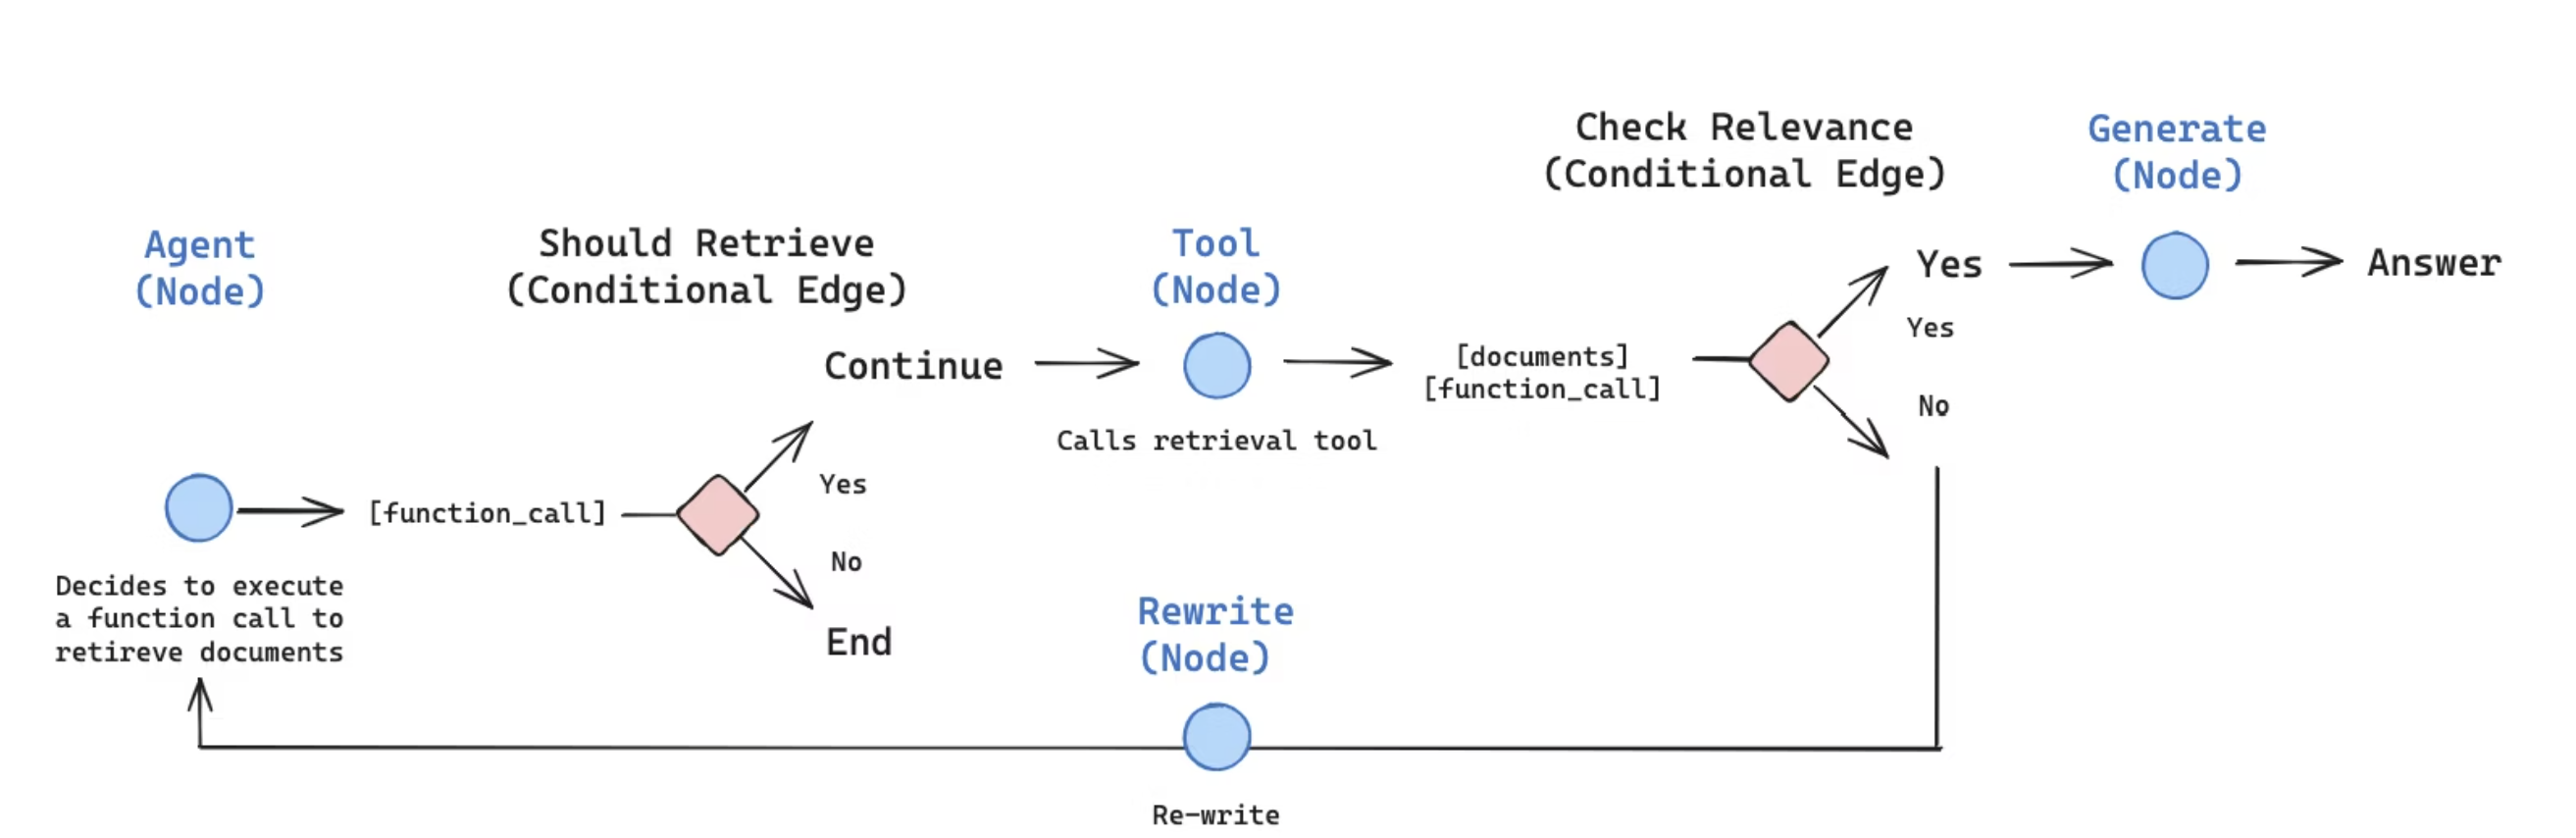

- 공식문서 상, retrieve 로 가져온 문서가 [Check Relevance] No의 흐름을 타게 되면, End 되어버리는 경우가 많다
- [Should Retrieve] 를 없애고, 사용자의 질문을 바로 retrieve 하는 구조로 변경해서 진행
    - rewrite 해서 바로 retrieve

In [3]:
# 생성된 벡터스토어에 접근 -> 클래스만 바로 써야 함
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'  # 로컬에 남아있음
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  # 검색할 때, 가장 유사한 3개의 문서를 가져오도록 설정

In [5]:
# state 생성

from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str   # 사용자의 질문
    context:List[Document]  # 답변을 만들때 참고할 문서들 - langchain의 다큐먼트들을 리스트 형태로 반환 
    answer: str


graph_builder = StateGraph(AgentState)  # 빌더 생성

In [ ]:
# 노드 생성

# retrieve
def retrieve(state:AgentState):
    query = state['query']  # 사용자의 질문을 꺼내온다
    docs = retriever.invoke(query)  # 사용자의 질문을 가지고 문서 검색
    return {'context' : docs}    # 검색된 결과를  state의 context에 넣어서 반환
